In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import os, tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from driver_genes.losses import edist_euclidean
import torch

Before simulating datasets with gradient strength, please download the raw data GSE182862_RAW.tar from [GSE182862](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE182862).


In [2]:
data_dir = './'

## preprocess raw data accroding to the paper

In [3]:
# raw case (updated)
target_dir = f"{data_dir}/hardeff"
os.makedirs(target_dir, exist_ok=True)

In [4]:
ad_ko = sc.read_10x_mtx(path=f"{data_dir}/raw", prefix="GSM5538788_KO_")
ad_wt = sc.read_10x_mtx(path=f"{data_dir}/raw", prefix="GSM5538787_WT_")

# merge
rad = sc.concat({
    'perturbed': ad_ko,
    'control': ad_wt
    }, axis=0, merge='unique', label='perturbation')
rad.obs_names_make_unique()
ad = rad.copy()

# filter cells with 1000-5000 genes and <12% mitochondrial genes
ad.var['mt'] = ad.var_names.str.startswith(('MT-', 'mt-'))
sc.pp.calculate_qc_metrics(
    ad, qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)
sc.pp.filter_cells(ad, min_genes=1000)
sc.pp.filter_cells(ad, max_genes=5000)
ad = ad[ad.obs.pct_counts_mt < 12]

# leave out Nelfb
ad.obs['Nelfb'] = ad[:,'Nelfb'].X.toarray().flatten()
ad = ad[:,ad.var_names != 'Nelfb']
sc.pp.filter_genes(ad, min_cells=1) # then remove genes with 0 counts in all cells

# normalize and log transform
ad.layers['raw'] = ad.X.copy()
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
# select highly variable genes
sc.pp.highly_variable_genes(
    ad, 
    n_top_genes=3000, 
    subset=False
)


In [5]:
# intra data DEGs
deg = sc.tl.rank_genes_groups(
    ad, 
    groupby='perturbation', 
    method='wilcoxon',
    reference='control',
    copy=True
)
deg_df = pd.DataFrame({
    'padj': deg.uns['rank_genes_groups']['pvals_adj']['perturbed'],
}, index=deg.uns['rank_genes_groups']['names']['perturbed'])

degs_refined = deg_df.index[deg_df['padj'] < 0.05]
ad.var['DEG'] = ad.var_names.isin(degs_refined)
ad.var['padj'] = list(map(
    lambda g: None if g not in deg_df.index 
    else deg_df.loc[g, 'padj'], 
    ad.var_names
))

# filter genes
ad_filtered = ad[:, ad.var.highly_variable | ad.var.DEG]
ad_filtered.layers['raw'] = ad_filtered.X.copy()
print(rad, "\n--->\n", ad_filtered)
print(f"There are {(ad_filtered.var['DEG']==False).sum()} non-DEGs.")
ad_filtered.write(f"{target_dir}_filtered.h5ad")

AnnData object with n_obs × n_vars = 13589760 × 31053
    obs: 'perturbation'
    var: 'gene_ids', 'feature_types' 
--->
 AnnData object with n_obs × n_vars = 4289 × 4152
    obs: 'perturbation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Nelfb'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'DEG', 'padj'
    uns: 'log1p', 'hvg'
    layers: 'raw'
There are 2678 non-DEGs.


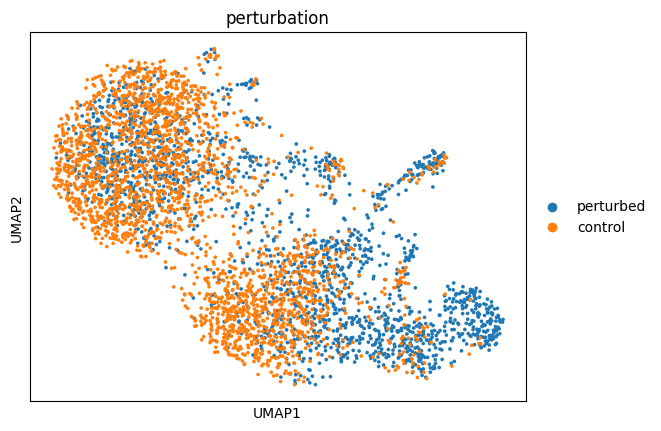

In [6]:
ad_filtered = sc.read_h5ad(f"{target_dir}_filtered.h5ad")
sc.pp.pca(ad_filtered)
sc.pp.neighbors(ad_filtered)
sc.tl.umap(ad_filtered)
sc.pl.umap(ad_filtered, color="perturbation")

## construct anndata with different number of DEGs and different perturbation efficiency

- #DEG: 10, 50, 100, 200, 500
- %efficiency: 0.05, 0.25, 0.5, 0.75, 1

In [7]:
def subsample_degs(ad, num_degs):
    nondegs = ad.var['DEG'][lambda x: x == False].sample(n=2500-num_degs).index
    ad_nondegs = ad[:, nondegs]
    ad_degs = ad[:, ad.var['DEG'] == True]
    degs_top = ad_degs.var.sort_values(by='padj', ascending=False).head(num_degs)
    ad_degs_top = ad_degs[:, degs_top.index]
    ad_subsampled = sc.concat([ad_degs_top, ad_nondegs], axis=1, merge='unique')
    return ad_subsampled


def subsample_perturbation(ad, ratio_eff, num_ctrl=2):
    ad.X = ad.X.toarray()
    ad_pert = ad[ad.obs['perturbation'] == 'perturbed']
    ad_ctrl = ad[ad.obs['perturbation'] == 'control']
    
    X_ctrl = ad_ctrl.X.copy()
    X_pert = ad_pert.X.copy()
    
    # randomly sample bcs from ad_pert to blurring the expression
    mask_blurred = np.random.rand(ad_pert.shape[0]) < (1 - ratio_eff)
    # mask_blurred = np.ones(ad_pert.shape[0], dtype=bool) # all perturbed bcs are blurred to efficiency ratio_eff
    # randomly sample num_ctrl bcs from ad_ctrl for each perturbed bc to blurring the expression
    index_ctrl4ctrl = np.random.choice(
        ad_ctrl.shape[0], 
        size=(ad_ctrl.shape[0], num_ctrl), 
        replace=True
    )
    index_ctrl4FP = np.random.choice(
        ad_ctrl.shape[0], 
        size=(mask_blurred.sum(), num_ctrl), 
        replace=True
    )
    index_pert4pert = np.random.choice(
        ad_pert.shape[0], 
        size=((mask_blurred==0).sum(), num_ctrl), 
        replace=True
    )
    ad_ctrl.X = X_ctrl[index_ctrl4ctrl, :].mean(axis=1)
    ad_pert.X[mask_blurred, :] = X_ctrl[index_ctrl4FP, :].mean(axis=1)
    ad_pert.X[mask_blurred==0, :] = X_pert[index_pert4pert, :].mean(axis=1)
    ad_pert.obs['blurred'] = mask_blurred
    ad_ctrl.obs['blurred'] = False
    ad_pert.obs['Nelfb_blurred'] = ad_pert.obs['Nelfb'].copy()
    ad_ctrl.obs['Nelfb_blurred'] = ad_ctrl.obs['Nelfb'].copy()
    ad_pert.obs['Nelfb_blurred'][mask_blurred] = ad_ctrl.obs['Nelfb'].values[index_ctrl4FP].mean(axis=1)
    ad_pert.obs['Nelfb_blurred'][mask_blurred==0] = ad_pert.obs['Nelfb'].values[index_pert4pert].mean(axis=1)
    ad_ctrl.obs['Nelfb_blurred'] = ad_ctrl.obs['Nelfb'].values[index_ctrl4ctrl].mean(axis=1)
    ad_subsampled = sc.concat([ad_pert, ad_ctrl], axis=0, merge='unique')
    return ad_subsampled


In [8]:
num_degs_list = [10, 50, 100, 200, 500]
ratio_eff_list = [0.05, 0.25, 0.5, 0.75, 1]
ad_sub_dict = {}
for num_degs in num_degs_list:
    ad_sub = subsample_degs(ad_filtered.copy(), num_degs)
    for ratio_eff in ratio_eff_list:
        ad_subsub = subsample_perturbation(ad_sub.copy(), ratio_eff)
        ad_sub_dict[f"{num_degs}_{ratio_eff}"] = ad_subsub
        sc.pp.pca(ad_subsub)
        sc.pp.neighbors(ad_subsub)
        sc.tl.umap(ad_subsub)

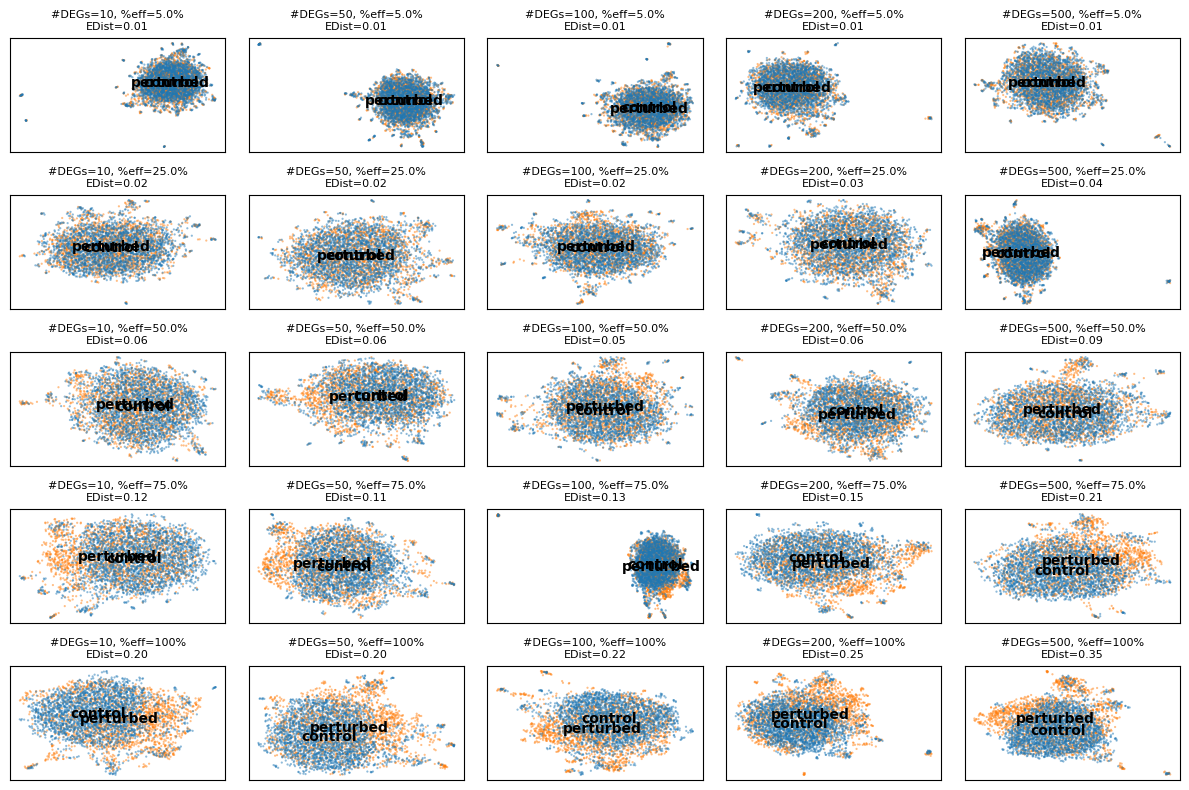

In [9]:
fig, axes = plt.subplots(len(ratio_eff_list), len(num_degs_list), figsize=(12, 8))
for j, num_degs in enumerate(num_degs_list):
    for i, ratio_eff in enumerate(ratio_eff_list):
        ad_sub = ad_sub_dict[f"{num_degs}_{ratio_eff}"]
        edist = edist_euclidean(
            torch.tensor(ad_sub[ad_sub.obs['perturbation'] == 'perturbed'].X, device='cuda:0'), 
            torch.tensor(ad_sub[ad_sub.obs['perturbation'] == 'control'].X, device='cuda:0')
        )
        
        sc.pl.umap(
            ad_sub, color="perturbation", 
            ax=axes[i, j], show=False,
            legend_loc='on data',
            alpha=0.5,
            size=10,
        )
        axes[i, j].set_title(
            f"#DEGs={num_degs}, %eff={ratio_eff*100}%\nEDist={edist.cpu().item():.2f}",
            fontsize=8,
        )
        axes[i, j].set_xlabel("")
        axes[i, j].set_ylabel("")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
plt.tight_layout()
plt.show()

In [10]:
for k, ad_sub in ad_sub_dict.items():
    ad_sub.write_h5ad(f"{target_dir}/simulation_{k}.h5ad")

## split dataset into training and testing sets

In [11]:
ad = sc.read_h5ad(f"{target_dir}_filtered.h5ad")
split_df = ad.obs.copy()
np.random.seed(42)
split_df['split'] = np.random.choice(['train', 'val', 'test'], size=len(split_df), p=[0.6, 0.1, 0.3])
split_df = split_df.reset_index(names='cell')[['cell', 'split']]
split_df.to_csv(f"{target_dir}/split_random.csv", index=False)
split_df

,cell,split
0,AAACCCATCCCGAGGT-1,train
1,AAACGAAGTCGCATTA-1,test
2,AAACGAAGTTAGGGTG-1,test
3,AAACGAAGTTCTTAGG-1,train
4,AAACGCTAGTTGTCAC-1,train
...,...,...
4284,TTTGACTAGTCGTTAC-1-1,train
4285,TTTGGAGCATACCGTA-1-1,train
4286,TTTGGAGTCAGACCCG-1-1,test
4287,TTTGGTTCAGGAATAT-1-1,train
